In [1]:
# %%
from core.Det import Det, DetData
import numpy as np
import matplotlib.pyplot as plt
from rich.table import Table
from rich import print
from hdf5storage import loadmat
import time
from core.AcqFunc import *

In [2]:
srv = DetData("10.20.77.2",50077)
dets = srv.findDet()
print(dets)
det = list(dets.items())[0][1]
srv.listen()

{'10.20.77.1': <core.Det.Det.Det object at 0x000001731E640880>}

In [3]:
# %% 状态信息
def dictPrint(d: dict, title="", k="", v=""):
    t = Table(title=title)
    t.add_column(k)
    t.add_column(v)
    [t.add_row(k, str(v)) for k, v in d.items()]
    print(t)
dictPrint(det.statusTemperature(), "温度")
dictPrint(det.statusPosition(0.0375), "位置")
dictPrint(det.statusPower(), "电源")
dictPrint(det.statusPowerSwitch(), "开关")
dictPrint(det.statusFanSpeed(), "风扇")

           温度            
┏━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃            ┃            ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ boardNum   │ 4          │
│ temperIO_0 │ 26.75      │
│ temperIO_1 │ 28.0       │
│ temper0_0  │ 27.0703125 │
│ temper0_1  │ 28.2265625 │
│ temper0_2  │ 29.8125    │
│ temper0_3  │ 29.734375  │
│ temper1_0  │ 26.9375    │
│ temper1_1  │ 28.1953125 │
│ temper1_2  │ 29.9609375 │
│ temper1_3  │ 30.3828125 │
│ temper2_0  │ 26.8203125 │
│ temper2_1  │ 27.9296875 │
│ temper2_2  │ 29.3046875 │
│ temper2_3  │ 29.734375  │
│ temper3_0  │ 26.046875  │
│ temper3_1  │ 27.5625    │
│ temper3_2  │ 29.203125  │
│ temper3_3  │ 29.40625   │
└────────────┴────────────┘

       位置        
┏━━━━━━━┳━━━━━━━━━┓
┃       ┃         ┃
┡━━━━━━━╇━━━━━━━━━┩
│ pos0A │ True    │
│ pos0B │ False   │
│ pos0  │ -1.0875 │
│ pos1A │ True    │
│ pos1B │ True    │
│ pos1  │ 0.0     │
└───────┴─────────┘

         电源         
┏━━━━━━━━━┳━━━━━━━━━━┓
┃         ┃          ┃
┡━━━━━━━━━╇━━━━━━━━━━┩
│ voltage │ 23.65875 │
│ currnet │ 2.191    │
│ power   │ 51.85    │
└─────────┴──────────┘

            开关             
┏━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃        ┃                  ┃
┡━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ vcc12  │ True             │
│ laser1 │ False            │
│ laser0 │ False            │
│ vdd25  │ 11111111         │
│ opa    │ 1111111111111111 │
│ vbias  │ 00000000         │
└────────┴──────────────────┘

        风扇        
┏━━━━━━━━━━━┳━━━━━━┓
┃           ┃      ┃
┡━━━━━━━━━━━╇━━━━━━┩
│ fanNum    │ 4    │
│ fanSpeed0 │ 1514 │
│ fanSpeed1 │ 1460 │
│ fanSpeed2 │ 1440 │
│ fanSpeed3 │ 1451 │
└───────────┴──────┘

In [4]:
# %% 电源及参数设置
det.setPositionConfig([
    {"pos": 0, "en": 1, "polarity": 0, "clearPos": 1, "zeroShift": 0},
    {"pos": 1, "en": 0, "polarity": 0, "clearPos": 1, "zeroShift": 0}])
det.setPowerSwitch({
    "laser1": 0, "laser0": 0, "opa": 1, "vbias": 1, "vcc12": 1, "vdd25": 1})
det.DetectRegSet(0x0018, 0x600003FF)
det.setWinNum(4)

detector run

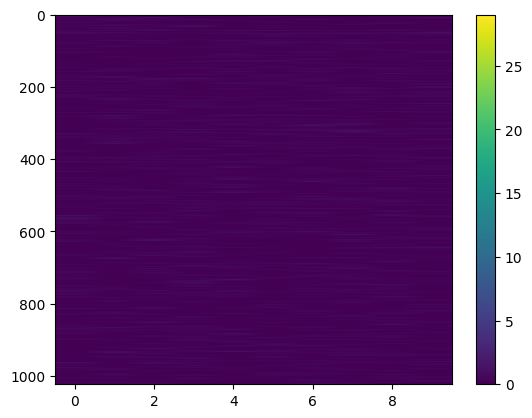

test

ERROR:root:没有足够的帧用于重建


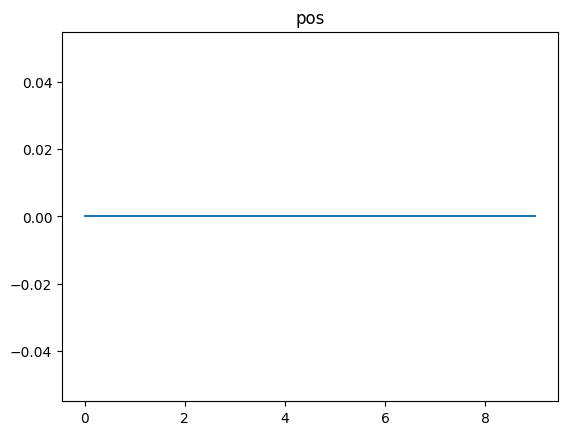

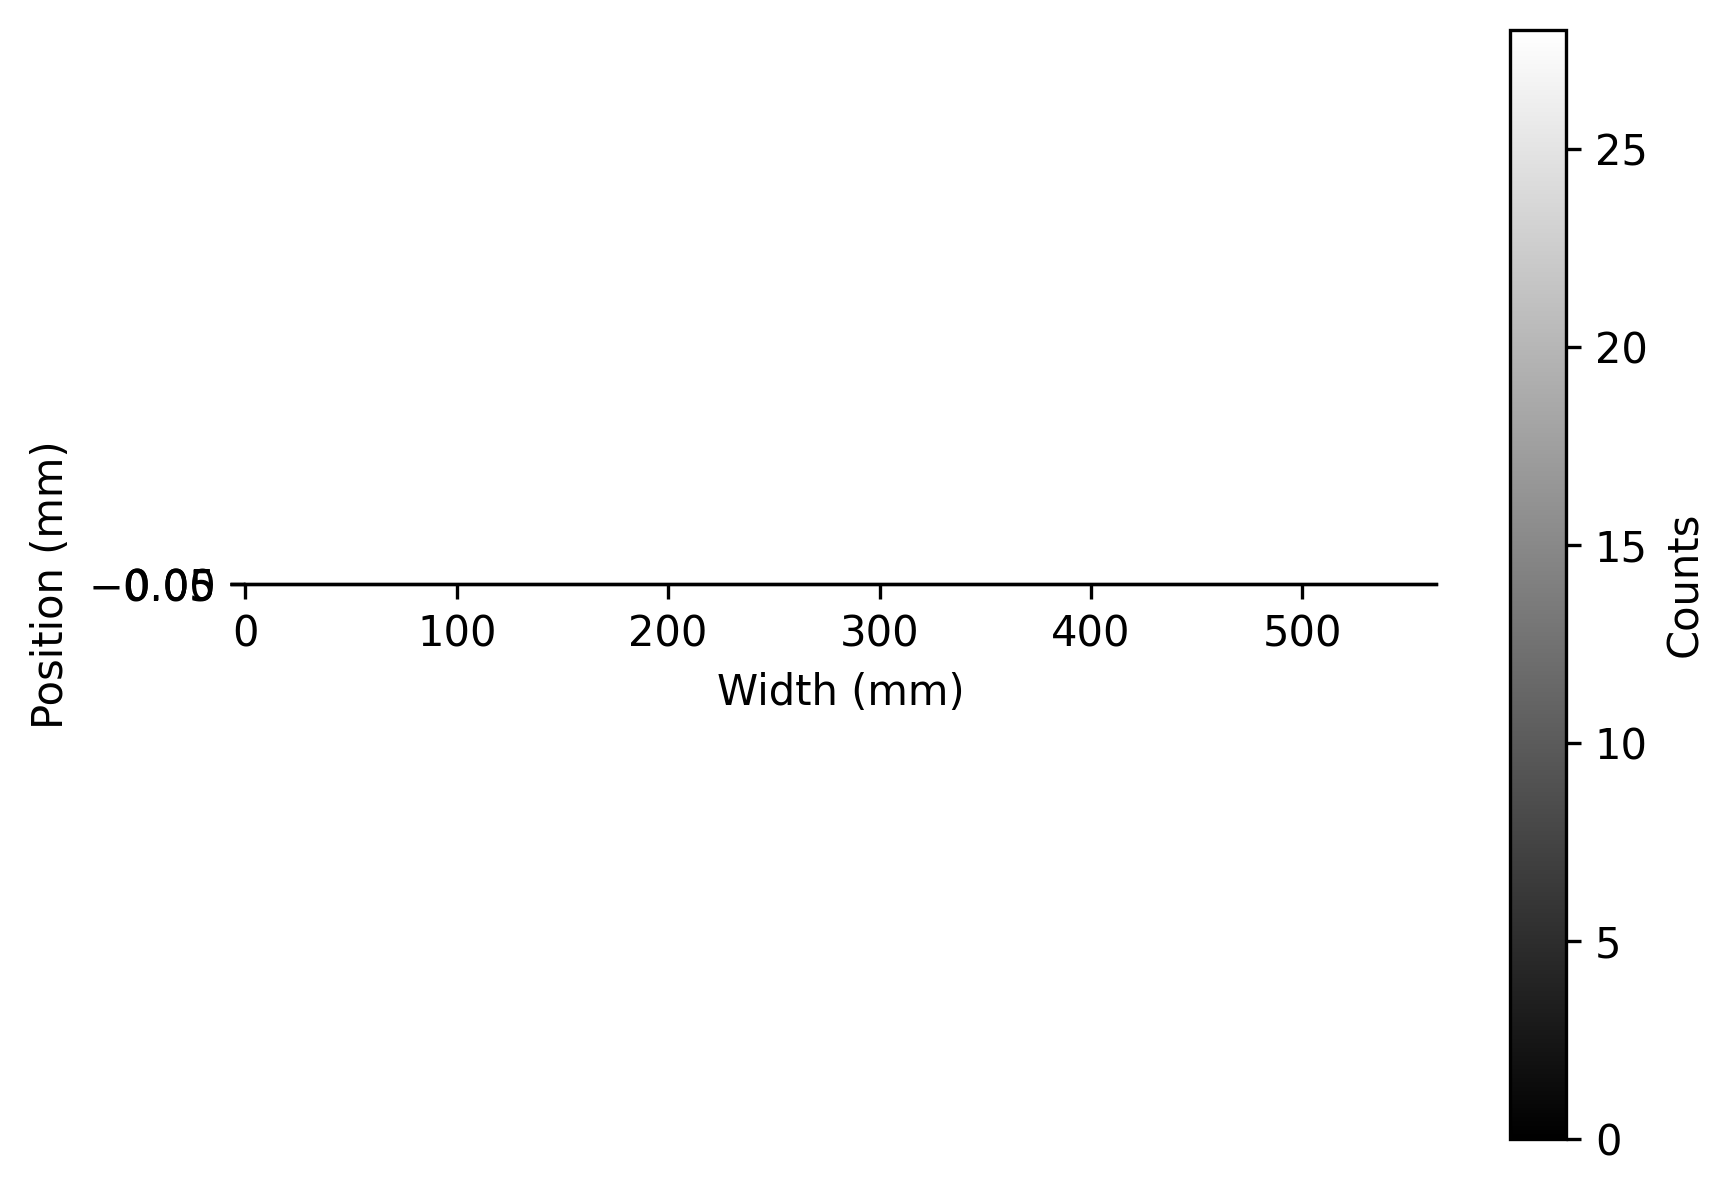

In [5]:
for i in range(1):
    # tube = f""
    # tube = f"_70kV_10mA"
    # filter = f"_0.3mmCu+0.3mmSn"
    # speed = f"_150mmps"
    name = f"test"

    subname = f"{name}"
    det.setWinRange(0, 0, 80)
    # time.sleep(4)
    print("detector run")
    # time.sleep(1)
    data = histAcqNoMove(det, cnt=None, time=4, interval = int(400 * 10))
    saveHist(data, subname, None)
    print(subname)
    showHist(
        data,
        pos_en=True,
        pos_step=0.0375,
        cal_sel=(400, 450),
        rate=1400/20,
        log_en=False,
        pos_limit=(0, 0),
        caxis=(0, 0),
        save_png=""
    )

In [ ]:
for i in range(1):
    # tube = f""
    tube = f"_75kV_110mA"
    # filter = f"_0.3mmCu+0.3mmSn"
    filter = f"_25mmAl"
    speed = f"_37.5mmps"
    freq = 500
    name = f"test2{speed}{filter}{tube}_{freq}hz"

    subname = f"{name}"
    det.setWinRange(0, 0, 99)
    det.setWinRange(1, 6, 21)
    det.setWinRange(2, 22, 40)
    det.setWinRange(3, 0, 90)
    print("detector run")
    data = thrAcqNoMove(det, cnt=None, time=8, interval = int(1000/freq * 10))
    saveThr(data, subname)
    print(subname)
    data2 = {
        "pos0h": data["pos0h"],
        "data": data["data"].reshape((data["data"].shape[0], -1, data["data"].shape[3]))
    }
    showHist(
        data2,
        pos_en=True,
        pos_step=0.0375,
        cal_sel=(400, 450),
        rate=1400/20,
        log_en=False,
        pos_limit=(0, 0),
        caxis=(0, 0),
        save_png=""
    )